## Plotting aligned parcellation maps across atlases

In [1]:
import os, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
from py_util_dx.py_utils import setProjectPath
from py_util_dx.data_utils import get_roi_vtx_from_fs32k, get_roi_pacels, get_glasser_labels
from scipy.stats import ttest_1samp
import Functional_Fusion.atlas_map as am 
import seaborn as sns 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import matplotlib as mpl 
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
import nibabel as nib
from visualizations import flatmap_real_vals
from nitools.cifti import surf_from_cifti
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import MDS
import matplotlib.colors as mcolors

In [2]:
mpl.rcParams['font.family'] = 'helvetica'   # Global font family
mpl.rcParams['font.size'] = 12              # Global font size 
full_width = 8.5
half_width = full_width/2

In [3]:
projectPath, mainResultsPath = setProjectPath()
dataset_name = 'MDTB' # or Demand
surface_helpers_dir = os.path.join(projectPath, 'surface_helpers')
resultsPath = os.path.join(mainResultsPath, 'START_A3_bayes_parcellation', f'{dataset_name}')

In [4]:
parcellations_of_interests = ['glasser', 'schaefer100']
Vs = []
n_parcels = [] 
roi = 'PFC' 
parcel_names = []

for parcellation in parcellations_of_interests:
    PKL_bayes_parcellation = os.path.join(resultsPath, parcellation, f'output_{roi}.pkl')
    with open(PKL_bayes_parcellation, 'rb') as pf:
        output = pickle.load(pf)
        V = output['V']
        Vs.append(V)
        n_parcels.append(V.shape[1])
        parcel_names.append(output['parcel_names_in_group']) 


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/traitlets/config/application.py",

In [5]:
Vs = np.hstack(Vs) 

In [6]:
Vs.shape 

(29, 76)

In [7]:
n_parcels

[44, 32]

In [8]:
D = 1 - cosine_similarity(Vs.T)
D.shape 

(76, 76)

In [9]:
mds = MDS(
    n_components=2,
    dissimilarity='precomputed',
    random_state=0,
    n_init=10,
    max_iter=300
)

X_joint = mds.fit_transform(D)  # (76, 2)

In [10]:
X_glasser = X_joint[:n_parcels[0]]
X_schaefer100 = X_joint[n_parcels[0]:] 

In [11]:
def embedding_to_rgb_hsv(X, S_max=0.85, V=0.9):
    x, y = X[:, 0], X[:, 1]

    hue = (np.arctan2(y, x) + np.pi) / (2 * np.pi)
    radius = np.sqrt(x**2 + y**2)

    saturation = np.clip(radius * S_max, 0, S_max)

    hsv = np.column_stack([hue, saturation, np.full(len(X), V)])
    rgb = mcolors.hsv_to_rgb(hsv)
    return rgb

In [12]:
color_rgb_glasser = embedding_to_rgb_hsv(X_glasser)
color_rgb_schaefer100 = embedding_to_rgb_hsv(X_schaefer100) 

In [13]:
color_rgb_glasser.shape 

(44, 3)

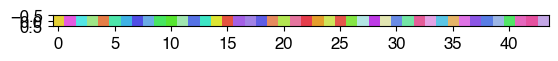

In [14]:
plt.imshow(color_rgb_glasser[np.newaxis, :]) 

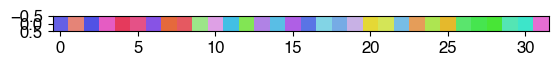

In [15]:
plt.imshow(color_rgb_schaefer100[np.newaxis, :]) 

In [ ]:
color_df_glasser = pd.DataFrame(data=color_rgb_glasser, index=parcel_names[0], columns=['r', 'g', 'b']) 
color_df_glasser

In [ ]:
temp_df = pd.read_csv(os.path.join(surface_helpers_dir, f'atl-glasser.lut'), sep=' ', header=None)  
temp_df = temp_df.rename(columns={0:'indx', 1:'r', 2:'g', 3:'b', 4:'roi'})
temp_df

In [ ]:
temp_df.index = temp_df['roi'].str.lstrip('LR_').str.rstrip('_ROI') 
temp_df

In [ ]:
temp_df.update(color_df_glasser)
temp_df

In [56]:
temp_df.to_csv(os.path.join(surface_helpers_dir, f'atl-glasser.lut'), sep=' ', index=False, header=False)

In [ ]:
# names = pd.read_csv(os.path.join(surface_helpers_dir, f'atl-schaefer100.lut'), header=None, skiprows=lambda x: x % 2 == 1)  
# names = names.rename(columns={0:'roi'})
# names 

In [ ]:
# colors = pd.read_csv(os.path.join(surface_helpers_dir, f'atl-schaefer100.lut'), header=None, skiprows=lambda x: x % 2 == 0, sep=' ')
# colors

In [ ]:
# temp_df = pd.merge(colors[[0, 1, 2, 3]], names, left_index=True, right_index=True) 
# temp_df

In [ ]:
# temp_df = temp_df.rename(columns={0: 'indx', 1: 'r', 2: 'g', 3: 'b'}) 
# temp_df

In [ ]:
# temp_df[['r', 'g', 'b']] /= 255 
# temp_df 

In [ ]:
# temp_df = temp_df.set_index('indx') 
# temp_df

In [16]:
temp_df = pd.read_csv(os.path.join(surface_helpers_dir, f'atl-schaefer100.lut'), sep='\s+', header=None, names=['indx', 'r', 'g', 'b', 'roi'])
temp_df 

,indx,r,g,b,roi
0,1,0.470588,0.070588,0.533333,17Networks_LH_VisCent_ExStr_1
1,2,0.470588,0.070588,0.537255,17Networks_LH_VisCent_ExStr_2
2,3,0.470588,0.070588,0.541176,17Networks_LH_VisCent_Striate_1
3,4,0.470588,0.070588,0.545098,17Networks_LH_VisCent_ExStr_3
4,5,1.000000,0.000000,0.007843,17Networks_LH_VisPeri_ExStrInf_1
...,...,...,...,...,...
95,96,0.019608,0.000000,0.513725,17Networks_RH_DefaultC_Rsp_1
96,97,0.019608,0.000000,0.517647,17Networks_RH_DefaultC_PHC_1
97,98,0.062745,0.188235,1.000000,17Networks_RH_TempPar_1
98,99,0.050980,0.160784,0.980392,17Networks_RH_TempPar_2


In [17]:
temp_df = temp_df.set_index('indx') 
temp_df 

,r,g,b,roi
indx,,,,
1,0.470588,0.070588,0.533333,17Networks_LH_VisCent_ExStr_1
2,0.470588,0.070588,0.537255,17Networks_LH_VisCent_ExStr_2
3,0.470588,0.070588,0.541176,17Networks_LH_VisCent_Striate_1
4,0.470588,0.070588,0.545098,17Networks_LH_VisCent_ExStr_3
5,1.000000,0.000000,0.007843,17Networks_LH_VisPeri_ExStrInf_1
...,...,...,...,...
96,0.019608,0.000000,0.513725,17Networks_RH_DefaultC_Rsp_1
97,0.019608,0.000000,0.517647,17Networks_RH_DefaultC_PHC_1
98,0.062745,0.188235,1.000000,17Networks_RH_TempPar_1


In [19]:
temp_df[0:20]

,r,g,b,roi
indx,,,,
1,0.470588,0.070588,0.533333,17Networks_LH_VisCent_ExStr_1
2,0.470588,0.070588,0.537255,17Networks_LH_VisCent_ExStr_2
3,0.470588,0.070588,0.541176,17Networks_LH_VisCent_Striate_1
4,0.470588,0.070588,0.545098,17Networks_LH_VisCent_ExStr_3
5,1.000000,0.000000,0.007843,17Networks_LH_VisPeri_ExStrInf_1
6,1.000000,0.000000,0.011765,17Networks_LH_VisPeri_StriCal_1
7,1.000000,0.000000,0.015686,17Networks_LH_VisPeri_ExStrSup_1
8,0.274510,0.509804,0.709804,17Networks_LH_SomMotA_1
9,0.274510,0.509804,0.713725,17Networks_LH_SomMotA_2


In [24]:
color_df_schaefer100 = pd.DataFrame(data=color_rgb_schaefer100, index=list(map(int, parcel_names[1])), columns=['r', 'g', 'b']) 
color_df_schaefer100.index.name = 'indx' 
color_df_schaefer100

,r,g,b
indx,,,
13,0.398554,0.378979,0.900000
20,0.900000,0.520775,0.466781
23,0.320479,0.322830,0.900000
25,0.900000,0.364017,0.766520
26,0.900000,0.228209,0.363890
27,0.900000,0.317970,0.531019
28,0.530652,0.328603,0.900000
32,0.900000,0.414542,0.236258
33,0.900000,0.350780,0.381066


In [25]:
temp_df.update(color_df_schaefer100)
temp_df[0:20]

,r,g,b,roi
indx,,,,
1,0.470588,0.070588,0.533333,17Networks_LH_VisCent_ExStr_1
2,0.470588,0.070588,0.537255,17Networks_LH_VisCent_ExStr_2
3,0.470588,0.070588,0.541176,17Networks_LH_VisCent_Striate_1
4,0.470588,0.070588,0.545098,17Networks_LH_VisCent_ExStr_3
5,1.000000,0.000000,0.007843,17Networks_LH_VisPeri_ExStrInf_1
6,1.000000,0.000000,0.011765,17Networks_LH_VisPeri_StriCal_1
7,1.000000,0.000000,0.015686,17Networks_LH_VisPeri_ExStrSup_1
8,0.274510,0.509804,0.709804,17Networks_LH_SomMotA_1
9,0.274510,0.509804,0.713725,17Networks_LH_SomMotA_2


In [26]:
color_df_schaefer100.index 

Index([13, 20, 23, 25, 26, 27, 28, 32, 33, 34, 38, 40, 44, 45, 46, 47, 57, 64,
       72, 74, 76, 77, 78, 81, 82, 85, 86, 90, 92, 93, 94, 95],
      dtype='int64', name='indx')

In [27]:
temp_df.index 

Index([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,  14,
        15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,
        29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,
        43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,
        57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,  70,
        71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,  84,
        85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98,
        99, 100],
      dtype='int64', name='indx')

In [28]:
temp_df.to_csv(os.path.join(surface_helpers_dir, f'atl-schaefer100.lut'), sep=' ', index=True, header=False) 